In [1]:
print("hello world")

hello world


In [2]:
import numpy as np
import pandas as pd
from parallel_pandas import ParallelPandas
ParallelPandas.initialize(n_cpu=12, split_factor=1)

from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource
output_notebook()

c:\Users\Orvil\miniconda3\envs\fakenewsproject\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading BokehJS ...

In [9]:
def replace_tokens(text: str):
    text = text.replace("< num >", "<num>")
    text = text.replace("< date >", "<date>")
    text = text.replace("< email >", "<email>")
    text = text.replace("< url >", "<url>")

    
    return text.split(" ")

In [10]:
total_counts = pd.Series()

In [ ]:
file_chunks = pd.read_csv("./../data/data_stemmed.csv", usecols=["content"], chunksize=50000)
for chunk_number, chunk in enumerate(file_chunks):
    data: pd.Series = chunk["content"]
    data = data.p_apply(replace_tokens)
    flattened = data.explode()
    counts = flattened.value_counts(sort=False)
    total_counts = total_counts.add(counts, fill_value=0)

REPLACE_TOKENS DONE: 100%|██████████| 24999/24999 [00:06<00:00, 4107.76it/s]


In [15]:
total_counts.sort_values(ascending=False)

content
,                  2398894.0
.                  1376352.0
<num>               913301.0
’                   490034.0
“                   307604.0
                     ...    
injunction.but           1.0
injunction.judg          1.0
injunction.san           1.0
injunction.to            1.0
🦅                        1.0
Length: 865601, dtype: object

In [ ]:
toplot = total_counts[0:1000]
toplot

content
,          2398894
.          1376352
<num>       913301
’           490034
“           307604
            ...   
что           5872
request       5870
paid          5867
beyond        5858
forward       5857
Name: count, Length: 1000, dtype: int64

In [9]:
bins = np.arange(0, len(toplot)-1)
hist, edges = np.histogram(toplot.to_numpy(), bins=bins)

In [10]:
source = ColumnDataSource(data={
    'x': np.arange(0, toplot.shape[0]),
    'token': toplot.index.tolist(),
    'y': toplot.values.tolist()
})

In [11]:
p = figure(height=400, 
           width=600,
           title="Bar Chart from Pandas Series",
           x_range=(0, toplot.shape[0]), 
           x_axis_type="linear",
           y_axis_type="log",
           tools="pan,wheel_zoom,box_zoom,save,reset,help,hover",
           tooltips=[("index", "@token"), ("count", "@y")],
           )
p.hover.mode = "vline"
p.step(x='x', y='y', source=source, line_width=2)
p.line(x='x', y='y', source=source, alpha=0) # For hover tool

GlyphRenderer(id='p1063', ...)

In [12]:
show(p)

<Axes: xlabel='content'>

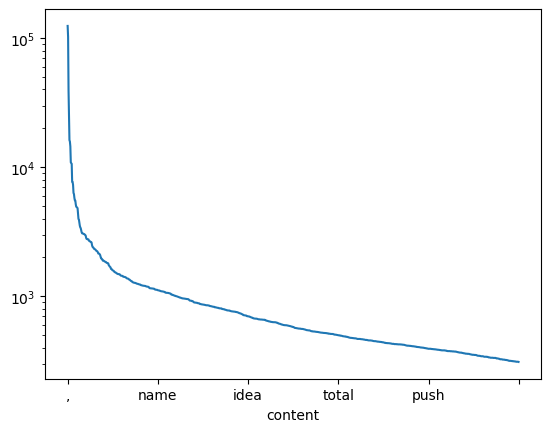

In [11]:
toplot.plot(kind='line',logy=True)